In [44]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import importlib
import pdslasso
import sim_data
from typing import Tuple, Dict, Any
import matplotlib.pyplot as plt 
import seaborn as sns 

# Force Python to re-read the file from disk
importlib.reload(sim_data)
importlib.reload(pdslasso)

<module 'pdslasso' from '/Users/ralfblochlinger/Documents/GitHub/post-double-selection-lasso/pdslasso.py'>

In [45]:
# example with simulated data
BETA = 3    

df, meta = sim_data.simulate_pds_data(true_effect=BETA)
control_cols = [col for col in df.columns if col.startswith("x")]
y_col = "y"
d_col = "d"

pds_lasso_obj = pdslasso.PDSLasso(df, y_col, d_col, control_cols)

fit_lasso = pds_lasso_obj.fit()
print(pds_lasso_obj.selected_controls)
fit_lasso.summary()

['x8', 'x47', 'x68', 'x59', 'x54', 'x93', 'x22', 'x25', 'x1', 'x23', 'x63', 'x58', 'x35', 'x60', 'x72', 'x46', 'x80', 'x85', 'x20', 'x4', 'x32', 'x88', 'x33', 'x50', 'x56', 'x49', 'x52', 'x45', 'x75', 'x57', 'x64', 'x70', 'x7', 'x6', 'x31', 'x94', 'x42', 'x34', 'x29', 'x0', 'x41', 'x48', 'x86', 'x5', 'x12', 'x2', 'x3', 'x16', 'x44', 'x17', 'x43']


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     100.9
Date:                Sat, 06 Dec 2025   Prob (F-statistic):               0.00
Time:                        16:42:20   Log-Likelihood:                -2065.4
No. Observations:                1000   AIC:                             4237.
Df Residuals:                     947   BIC:                             4497.
Df Model:                          52                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0184      0.121      0.152      0.879      -0.219       0.256
d              2.9909      0.198     15.139      0.000       2.604       3.378
x8             1.0870      0.061     17.689      0.000       0.967       1.207
x47           -0.1983      0.059     -3.387      0.001      -0.313      -0.084
x68           -0.0612      0.065     -0.948      0.343      -0.188       0.065
x59           -0.1061      0.067     -1.574      0.116      -0.238       0.026
x54           -0.0302      0.060     -0.503      0.615      -0.148       0.088
x93           -0.0413      0.066     -0.630      0.529      -0.170       0.087
x22           -0.0385      0.068     -0.567      0.571      -0.171       0.094
x25           -0.1486      0.060     -2.494      0.013      -0.265      -0.032
x1            -1.4244      0.073    -19.585      0.000      -1.567      -1.282
x23           -0.0090      0.069     -0.130      0.897      -0.144       0.126
x63            0.0222      0.066      0.335      0.738      -0.108       0.152
x58            0.1293      0.060      2.140      0.032       0.011       0.248
x35            0.0898      0.065      1.388      0.165      -0.037       0.217
x60            0.0144      0.064      0.224      0.823      -0.111       0.140
x72            0.1519      0.060      2.527      0.011       0.034       0.270
x46           -0.0373      0.058     -0.641      0.521      -0.151       0.077
x80            0.0113      0.061      0.184      0.854      -0.109       0.131
x85            0.0574      0.068      0.845      0.398      -0.076       0.191
x20            0.0213      0.063      0.337      0.736      -0.103       0.146
x4             0.0932      0.069      1.355      0.175      -0.042       0.228
x32           -0.0509      0.062     -0.828      0.408      -0.172       0.070
x88           -0.1107      0.070     -1.593      0.111      -0.247       0.026
x33           -0.0160      0.064     -0.251      0.802      -0.141       0.109
x50            0.1482      0.063      2.349      0.019       0.025       0.272
x56            0.0207      0.067      0.310      0.757      -0.110       0.152
x49           -0.0958      0.063     -1.532      0.126      -0.218       0.027
x52            0.1165      0.064      1.816      0.069      -0.009       0.242
x45            0.1515      0.062      2.428      0.015       0.029       0.274
x75           -0.0157      0.063     -0.249      0.803      -0.139       0.108
x57           -0.1417      0.066     -2.138      0.033      -0.272      -0.012
x64           -0.0615      0.067     -0.915      0.360      -0.193       0.070
x70            0.0930      0.063      1.470      0.142      -0.031       0.217
x7             0.9149      0.061     15.059      0.000       0.796       1.034
x6             0.9918      0.061     16.183      0.000       0.872       1.112
x3

In [46]:
# monte carlo simulation
beta_hat_list = []

N_sim = 500

for i in range(N_sim):

    df, meta = sim_data.simulate_pds_data(true_effect=BETA, random_seed=i)
    control_cols = [col for col in df.columns if col.startswith("x")]
    y_col = "y"
    d_col = "d"

    pds_lasso_obj = pdslasso.PDSLasso(df, y_col, d_col, control_cols)
    fit_lasso = pds_lasso_obj.fit()
    beta_hat_pds = fit_lasso.params["d"]

    # regular lasso
    X_controls = pd.DataFrame(StandardScaler().fit_transform(df[control_cols]))
    X_controls.columns = control_cols
    X = pd.concat([df[d_col], X_controls], axis=1)
    y = df[y_col]

    regular_lasso = LassoCV().fit(X,y)
    beta_hat_lasso = regular_lasso.coef_[0]

    # regular regression
    regular_reg = sm.OLS(endog=y, exog=sm.add_constant(df[d_col])).fit()
    beta_hat_ols = regular_reg.params["d"]

    beta_hat_list.append({
        "pds": beta_hat_pds, 
        "lasso": beta_hat_lasso, 
        "ols": beta_hat_ols
        })
    

beta_hat_df = pd.DataFrame(beta_hat_list)

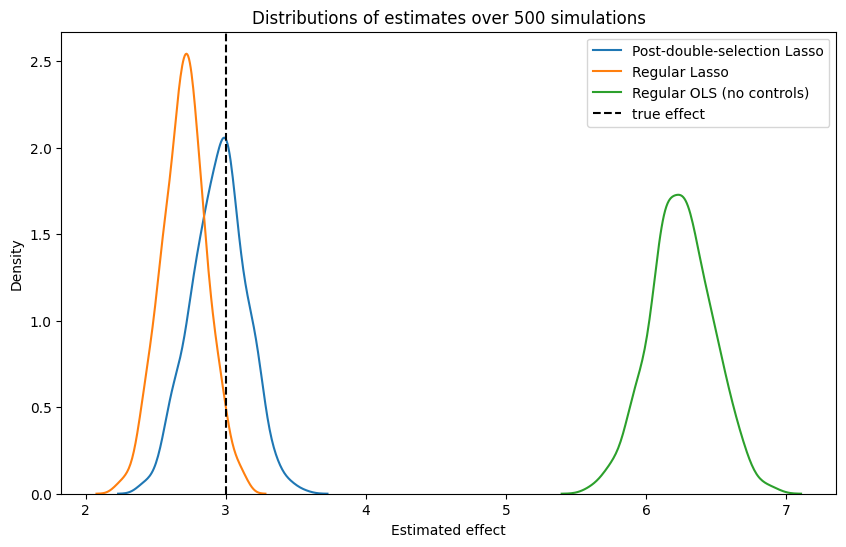

In [47]:
# plot distributions of estimates 
plt.figure(figsize=(10,6))
sns.kdeplot(beta_hat_df["pds"], label="Post-double-selection Lasso")
sns.kdeplot(beta_hat_df["lasso"], label="Regular Lasso")
sns.kdeplot(beta_hat_df["ols"], label="Regular OLS (no controls)")
plt.axvline(BETA, color="black", linestyle="--", label="true effect")
plt.legend()
plt.title(f"Distributions of estimates over {N_sim} simulations")
plt.xlabel("Estimated effect")
plt.ylabel("Density")
plt.show()